# MMFDB · Confocal imaging (CLSM)

A **confocal laser-scanning** measurement is a photon stream annotated with
frame/line/pixel markers. We simulate a raster scan of a star-shaped sample
with tttrlib, store the raw event stream in **MMFDB**, fetch it back, and
reconstruct the image.

In [1]:
%matplotlib inline
import logging, warnings
for _n in ("numexpr", "mmfdb"):
    logging.getLogger(_n).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="nopython is set for njit")

import numpy as np
import matplotlib.pyplot as plt
import tttrlib
from pathlib import Path
import tempfile
from chisurf.plugins.burst.burst_analysis.api import BurstWorkflow

## Simulate a raster scan

One immobile fluorophore per 'on' pixel of a star mask, scanned pixel by pixel.

In [2]:
N, PX = 24, 0.5
yy, xx = np.mgrid[0:N, 0:N]; cx = cy = (N - 1) / 2
ang = np.arctan2(yy - cy, xx - cx); rad = np.hypot(xx - cx, yy - cy)
mask = (rad <= 4 + 6 * np.abs(np.cos(2.5 * ang))).astype(int)

sample = tttrlib.SimSystem()
sp = tttrlib.SimSpecies(); sp.D = 0.0; sp.q = tttrlib.VectorDouble([2000.0])
sample.add_species(sp)
sample.set_rate_matrices([0.0], [0.0]); sample.set_background([0.0])
for iy in range(N):
    for ix in range(N):
        if mask[iy, ix]:
            sample.add_fluorophore(ix * PX, iy * PX, 0.0, 0, False)

exc = tttrlib.SimGrid.gaussian3d(0.2, 1.0, 0.8, 1.0, 0.04, 1.0)
integ = tttrlib.SimIntegrator(); integ.dt = 0.01; integ.n_channels = 1; integ.n_ph_max = 10**9
engine = tttrlib.SimEngine(sample, exc, tttrlib.VectorSimGrid([]), integ)
scanner = tttrlib.SimScanner.uniform(N, N, dwell=0.05, pixel_dx=PX, pixel_dy=PX,
                                     origin_x=0.0, origin_y=0.0,
                                     markers=tttrlib.SimMarkerConfig(), bidirectional=False)
engine.run_scan(scanner)
macro = np.array(engine.macro_window(), dtype=np.uint64)
micro = np.zeros(len(macro), dtype=np.uint16)
routing = np.array(engine.channel(), dtype=np.int8)
event = np.array(engine.event_type(), dtype=np.int8)   # 0 photon, 1 marker
print(f"{int((event==0).sum())} photons, {int((event==1).sum())} scan markers")

20110 photons, 625 scan markers


## Store the raw scan in MMFDB, then fetch it back

The marker-annotated event stream is saved losslessly and registered; a
downstream client pulls it back by handle.

In [3]:
tmp = Path(tempfile.mkdtemp()) / "clsm_scan.npz"
np.savez(tmp, macro=macro, micro=micro, routing=routing, event=event)

wf = BurstWorkflow.demo()
handle = wf.register(tmp)
arrays = np.load(wf.fetch(handle))
print("fetched scan from MMFDB handle", handle[:8])

fetched scan from MMFDB handle e480a5d0


## Reconstruct the image

tttrlib's `CLSMImage` uses the markers to bin photons back into pixels.

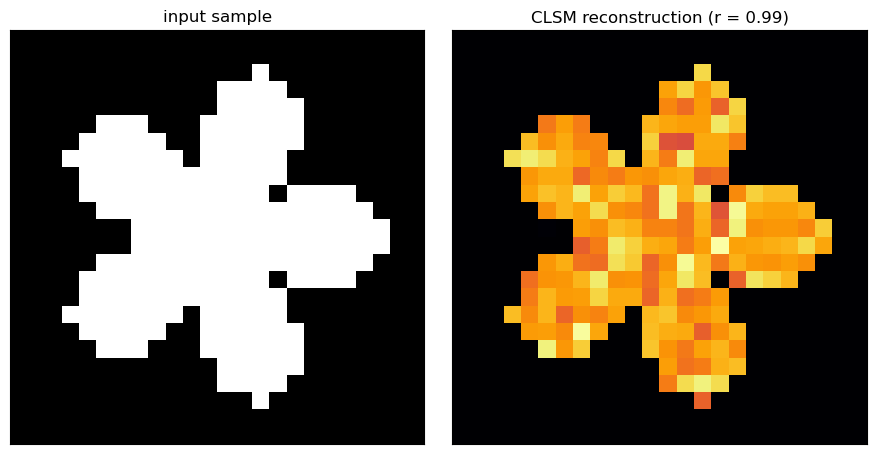

In [4]:
data = tttrlib.TTTR(arrays["macro"].astype(np.uint64), arrays["micro"].astype(np.uint16),
                    arrays["routing"].astype(np.int8), arrays["event"].astype(np.int8))
clsm = tttrlib.CLSMImage(tttr_data=data, marker_frame_start=[4], marker_line_start=1,
                         marker_line_stop=2, n_pixel_per_line=N, use_pixel_markers=True,
                         marker_pixel=8, settings={"n_lines": N})
clsm.fill()
image = np.array(clsm.intensity)[0]
corr = np.corrcoef(image.ravel(), mask.ravel())[0, 1]

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(mask, origin="lower", cmap="gray"); ax[0].set_title("input sample")
ax[1].imshow(image, origin="lower", cmap="inferno")
ax[1].set_title(f"CLSM reconstruction (r = {corr:.2f})")
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

In [5]:
wf.close()
print("Finished.")

Finished.
